In [43]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from PIL import Image as im

## Buatlah fungsi konvolusi

In [44]:

def pad_image(image, pad, mode="zero"):
    image = np.array(image)
    if pad == 0:
        return image
    
    if image.ndim == 2:  # grayscale
        pad_width = ((pad, pad), (pad, pad))
    elif image.ndim == 3:  # RGB
        pad_width = ((pad, pad), (pad, pad), (0, 0))
    else:
        raise ValueError("Image harus 2D (grayscale) atau 3D (RGB).")
    
    if mode == "zero":
        return np.pad(image, pad_width, mode="constant", constant_values=0)
    elif mode == "replicate":
        return np.pad(image, pad_width, mode="edge")
    elif mode == "reflect":
        return np.pad(image, pad_width, mode="reflect")
    else:
        raise ValueError("Mode harus 'zero', 'replicate', atau 'reflect'.")



def convolution2d(image, kernel, stride=1, padding=0, mode="zero"):
    # lakukan padding
    image = pad_image(image, padding, mode)

    i_h, i_w = image.shape
    k_h, k_w = kernel.shape

    # ukuran output
    o_h = (i_h - k_h)//stride + 1
    o_w = (i_w - k_w)//stride + 1

    # siapkan output
    output = np.zeros((o_h, o_w))

    # loop konvolusi
    for y in range(o_h):
        for x in range(o_w):
            val = 0
            for k1 in range(k_h):
                for k2 in range(k_w):
                    val += kernel[k1, k2] * image[y*stride + k1, x*stride + k2]
            output[y, x] = val

    return output


In [45]:
img = cv.imread('../images/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

## Sharpen

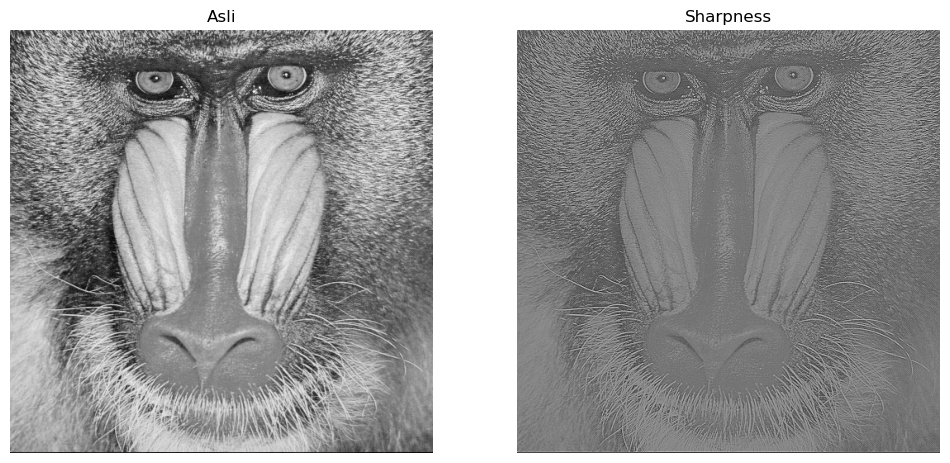

In [46]:
kernel_sharpen = np.array([[0, -1, 0],
                           [-1, 5, -1],
                           [0, -1, 0]])
result_repl = convolution2d(img_gray, kernel_sharpen, stride=1, padding=1, mode="replicate")

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img_gray, cmap="gray")
axs[0].set_title("Asli")
axs[0].axis("off")

axs[1].imshow(result_repl, cmap="gray")
axs[1].set_title("Sharpness")
axs[1].axis("off")
plt.show()

## Embos

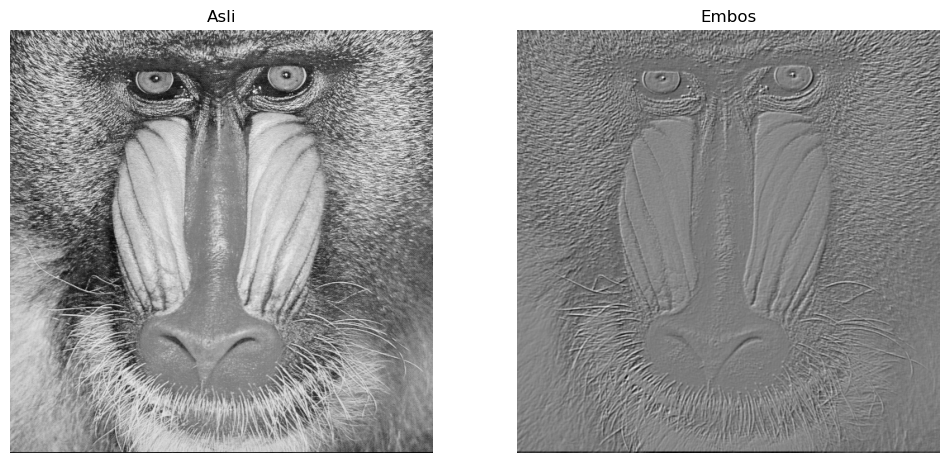

In [47]:
kernel_embos = np.array([[-2, -1, 0],
                           [-1, 1, 1],
                           [0, 1, 2]])
result_repl = convolution2d(img_gray, kernel_embos, stride=1, padding=1, mode="replicate")

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img_gray, cmap="gray")
axs[0].set_title("Asli")
axs[0].axis("off")

axs[1].imshow(result_repl, cmap="gray")
axs[1].set_title("Embos")
axs[1].axis("off")
plt.show()

## Left Sobel Edge Detection

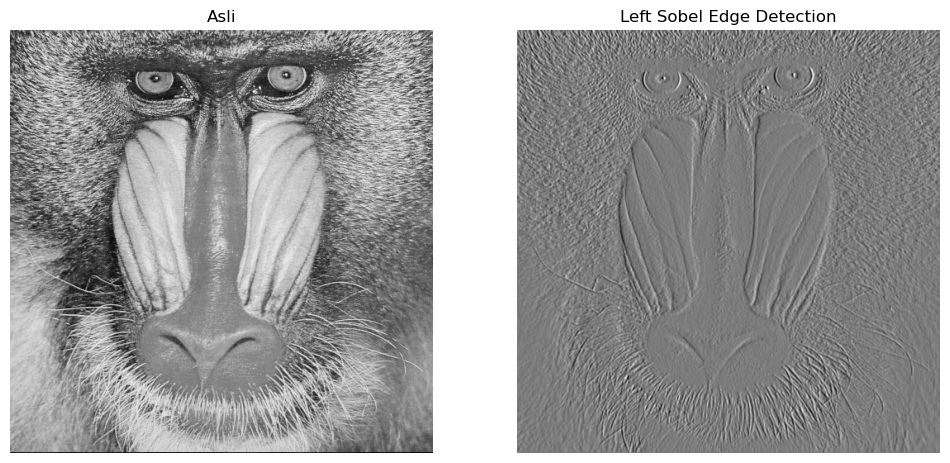

In [48]:
kernel_left_sobel_edge = np.array([[1, 0, -1],
                                    [2, 0, -2],
                                    [1, 0, -1]])
result_repl = convolution2d(img_gray, kernel_left_sobel_edge, stride=1, padding=1, mode="replicate")

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img_gray, cmap="gray")
axs[0].set_title("Asli")
axs[0].axis("off")

axs[1].imshow(result_repl, cmap="gray")
axs[1].set_title("Left Sobel Edge Detection")
axs[1].axis("off")
plt.show()

## Canny Edge Detection

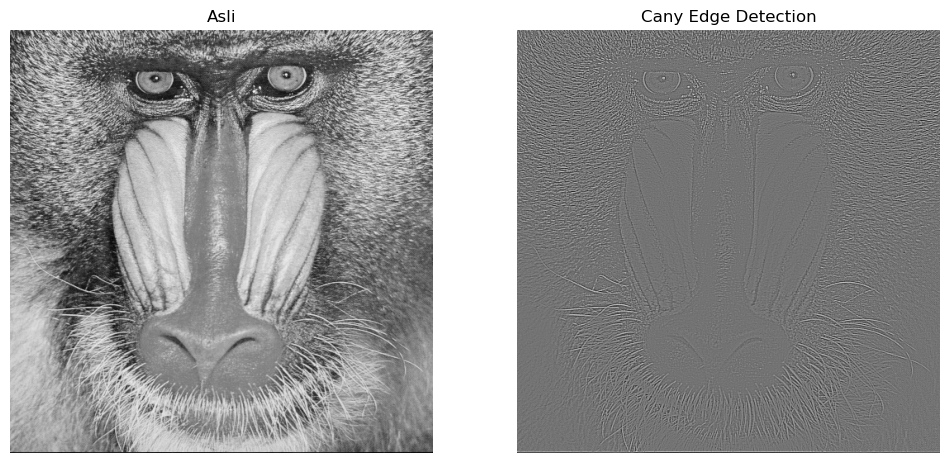

In [49]:
kernel_cany_edge = np.array([[-1, -1, -1],
                            [-1, 8, -1],
                            [-1, -1, -1]])
result_repl = convolution2d(img_gray, kernel_cany_edge, stride=1, padding=1, mode="replicate")

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img_gray, cmap="gray")
axs[0].set_title("Asli")
axs[0].axis("off")

axs[1].imshow(result_repl, cmap="gray")
axs[1].set_title("Cany Edge Detection")
axs[1].axis("off")
plt.show()

## Gaussian Blur

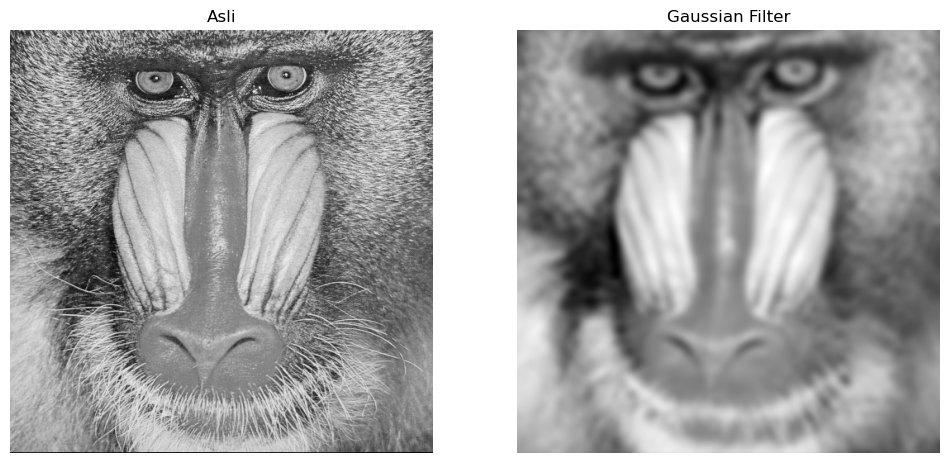

In [50]:
kernel_size = 20
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gaussian_kernel = gaussian_kernel @ gaussian_kernel.transpose()

result_repl = convolution2d(img_gray, gaussian_kernel, stride=1, padding=1, mode="replicate")

fig, axs = plt.subplots(1, 2, figsize=(12,6))
axs[0].imshow(img_gray, cmap="gray")
axs[0].set_title("Asli")
axs[0].axis("off")

axs[1].imshow(result_repl, cmap="gray")
axs[1].set_title("Gaussian Filter")
axs[1].axis("off")
plt.show()

# E. FILTER LIBRARY DAN FILTER MODERN

In [51]:
# Fungsi tampil berdampingan
def show_side_by_side(images, titles, figsize=(15,5)):
    plt.figure(figsize=figsize)
    for i, (img, title) in enumerate(zip(images, titles)):
        if len(img.shape) == 2: # grayscale
            plt.subplot(1, len(images), i+1)
            plt.imshow(img, cmap="gray")
        else: # color
            plt.subplot(1, len(images), i+1)
            plt.imshow(cv.cvtColor(img, cv.COLOR_BGR2RGB))
        plt.title(title)
        plt.axis("off")
    plt.show()


In [52]:
img = cv.imread('../images/lena.jpg')
img_gray = cv.cvtColor(img,cv.COLOR_BGR2GRAY)

## Filter Gaussian, Sharpen, dan Canny menggunakan library filter2d dari OpenCV

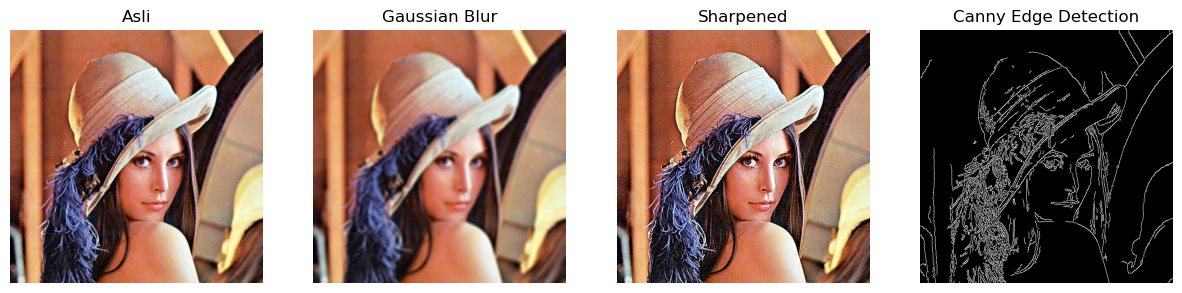

In [53]:
blur = cv.GaussianBlur(img, (7,7), 10)
edges = cv.Canny(cv.cvtColor(img, cv.COLOR_BGR2GRAY), 100, 200)
sharpen_kernel = np.array([[0,-1,0],[-1,5,-1],[0,-1,0]])
sharpened = cv.filter2D(img, -1, sharpen_kernel)
show_side_by_side([img, blur, sharpened, edges],
                  ["Asli", "Gaussian Blur", "Sharpened", "Canny Edge Detection"])

## Bilateral Filtering dan Guided Filter.

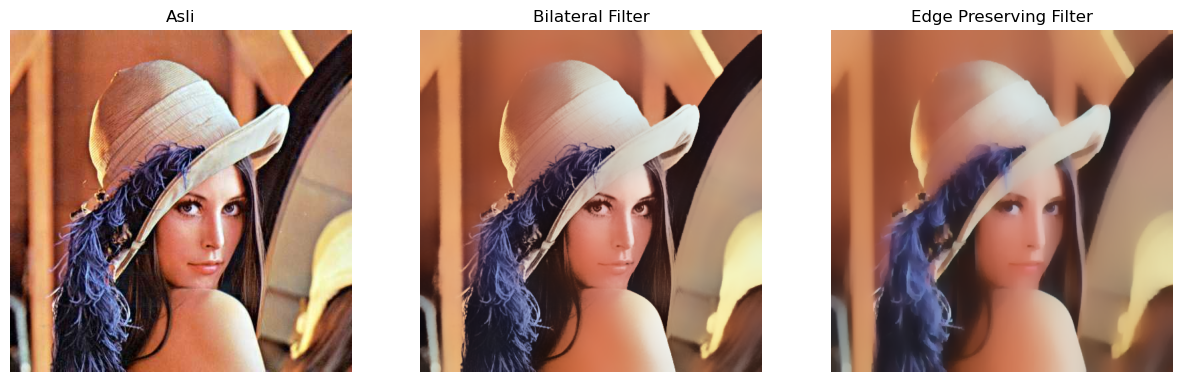

In [54]:
# Filter modern dari OpenCV
# Bilateral Filter (edge-preserving)
bilateral = cv.bilateralFilter(img, 50, 100, 100)

# Edge Preserving Filter (alternatif untuk Guided Filter)
edge_preserving = cv.edgePreservingFilter(img, flags=1, sigma_s=100, sigma_r=0.9)

show_side_by_side([img, bilateral, edge_preserving],
                  ["Asli", "Bilateral Filter", "Edge Preserving Filter"])

## Filtering pada CNN (bagian Feature Map)

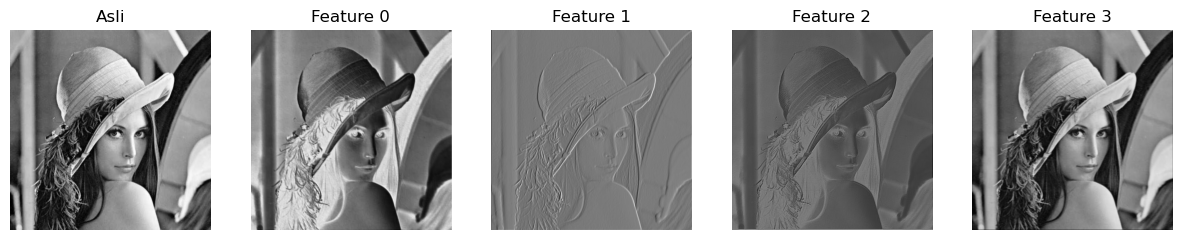

In [55]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 4, kernel_size=3, stride=1, padding=1)
    
    def forward(self, x):
        return self.conv1(x)

model = SimpleCNN()


# Ubah gambar ke tensor
img_tensor = torch.tensor(img_gray, dtype=torch.float32).unsqueeze(0).unsqueeze(0) / 255.0

# Hasil CNN
with torch.no_grad():
    features = model(img_tensor)
    
# Visualisasi feature maps
feature_maps = [features[0, i].numpy() for i in range(features.shape[1])]
show_side_by_side([img_gray] + feature_maps, ["Asli"] + ["Feature {}".format(i) for i in range(len(feature_maps))])

## Percobaan 4: Beauty dan Vintage yang

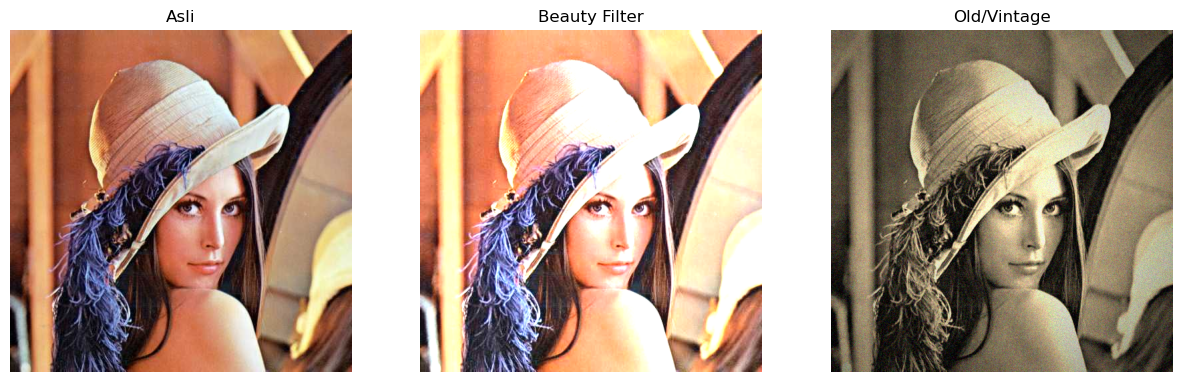

In [56]:
# ==============
# 1 Beauty Filter
# ==============
# Step 1: Smoothing kulit dengan bilateral filter
smooth = cv.bilateralFilter(img, d=15, sigmaColor=75, sigmaSpace=75)

# Step 2: Unsharp masking (pertajam mata/bibir)
gaussian = cv.GaussianBlur(img, (0,0), 3)
sharpened = cv.addWeighted(img, 1.5, gaussian, -0.5, 0)

# Step 3: Brightness dan kontras
alpha = 1.5
beta = 15
bright = cv.convertScaleAbs(img, alpha=alpha, beta=beta)

# ==============
# 2 Old/Vintage Filter
# ==============

# Step 1: Sepia tone
sepia_kernel = np.array([[0.272, 0.534, 0.131],
                         [0.349, 0.686, 0.168],
                         [0.393, 0.769, 0.189]])
sepia = cv.transform(img, sepia_kernel)
sepia = np.clip(sepia, 0, 255).astype(np.uint8)

# Step 2: Vignette
rows, cols = img.shape[:2]
kernel_x = cv.getGaussianKernel(cols, cols*0.6)
kernel_y = cv.getGaussianKernel(rows, rows*0.6)
kernel = kernel_y * kernel_x.T
mask = kernel / kernel.max()
vignette = np.copy(sepia)
for i in range(3):
    vignette[:,:,i] = vignette[:,:,i] * mask

# Step 3: Noise/Grain
noise = np.random.normal(0, 15, vignette.shape).astype(np.int16)
old_img = np.clip(vignette.astype(np.int16) + noise, 0, 255).astype(np.uint8)

show_side_by_side([img,  bright, old_img],
                  ["Asli", "Beauty Filter", "Old/Vintage"])

## Percobaan 5: Filter Anime / Cartoon

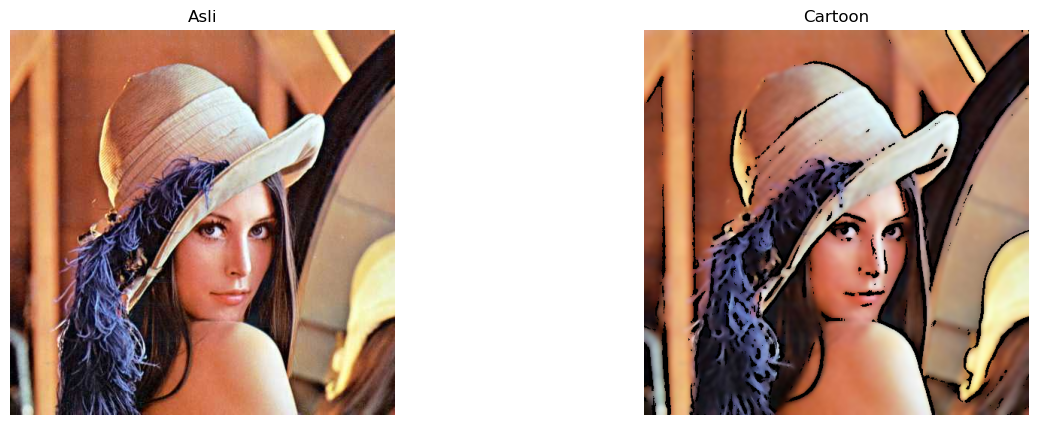

In [57]:
# Filter Cartoon
# Step 1: Edge Detection
gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
gray_blur = cv.medianBlur(gray, 7)
edges = cv.adaptiveThreshold(gray_blur, 255, cv.ADAPTIVE_THRESH_MEAN_C, cv.THRESH_BINARY, 9, 9)

# Step 2: Bilateral Filter untuk smoothing warna
color = cv.bilateralFilter(img, d=9, sigmaColor=200, sigmaSpace=200)

# Step 3: Gabungkan
cartoon = cv.bitwise_and(color, color, mask=edges)

show_side_by_side([img, cartoon],
                  ["Asli", "Cartoon"])

## Percobaan 6: Filter Malam

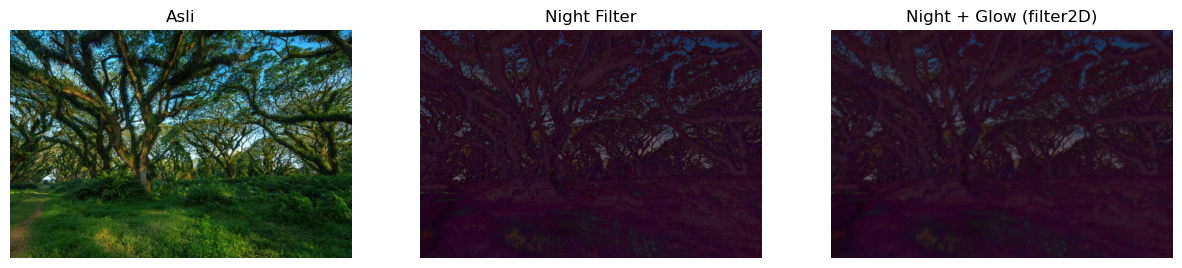

In [58]:
# Night Filter
djawatan = cv.imread('../images/djawatan.jpg')
djawatan_gray = cv.cvtColor(djawatan,cv.COLOR_BGR2GRAY)

# Step 1: Gelapkan (contrast turun, brightness negatif)
night = cv.convertScaleAbs(djawatan, alpha=0.6, beta=-40)

# Step 2: Tambah bias biru
blue_tint = np.full_like(night, (50, 0, 100)) # BGR
night = cv.addWeighted(night, 0.8, blue_tint, 0.2, 0)

# Step 3: Efek glow di area terang dengan filter2D (blur kernel)
kernel = np.ones((15,15), np.float32) / 225
glow = cv.filter2D(night, -1, kernel)

# Kombinasikan asli + glow
night_glow = cv.addWeighted(night, 0.7, glow, 0.3, 0)

show_side_by_side([djawatan, night, night_glow],
                  ["Asli", "Night Filter", "Night + Glow (filter2D)"])

## Percobaan 7: Filter Pagi dan Pagi

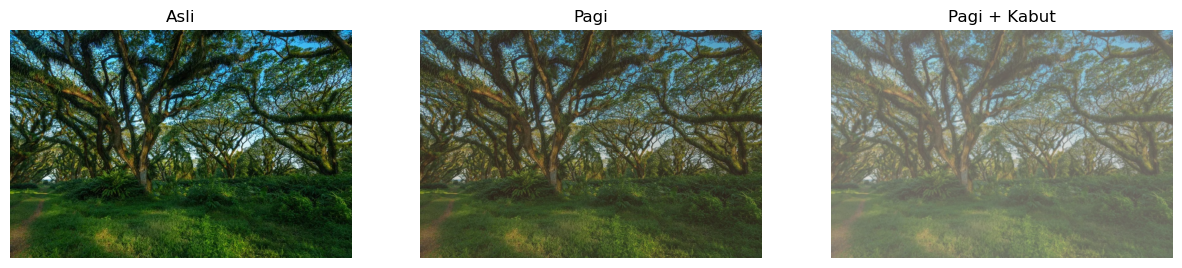

In [59]:
#Filter Suasana pagi dan Kabut
# ========================
# Step 1: Kurangi kontras & cerahkan
# ========================
alpha = 0.9  # contrast
beta = 20    # brightness
soft = cv.convertScaleAbs(djawatan, alpha=alpha, beta=beta)

# ========================
# Step 2: Tambahkan warm tone (kemerahan / oranye)
# ========================
warm_tint = np.full_like(soft, (40, 70, 120)) # BGR
pagi = cv.addWeighted(soft, 0.8, warm_tint, 0.2, 0)

# ========================
# Step 3: Tambahkan haze (kabut tipis) dengan filter2D
# ========================
# Kernel blur Gaussian-like untuk menciptakan efek kabut
kernel = cv.getGaussianKernel(3, 3)
kernel = kernel @ kernel.T # jadikan 2D kernel
kabut = cv.filter2D(pagi, -1, kernel)

# tambah layer putih untuk kabut lebih nyata
white_layer = np.full_like(pagi, 255)
kabut = cv.addWeighted(kabut, 0.7, white_layer, 0.3, 0)

show_side_by_side([djawatan, pagi, kabut],
                  ["Asli", "Pagi", "Pagi + Kabut"])